In [1]:
from supabase import create_client

supabase_url = "https://ltzghyyhqglwqcwusmlt.supabase.co"
supabase_key = "sb_publishable_o-FY0g6pPRvMD4RySMY4tA_f6L_Rbxp"

supabase = create_client(supabase_url, supabase_key)

print("Supabase connection successful!")

Supabase connection successful!


In [2]:
import pandas as pd

response = supabase.table("insurance_claims").select("*").execute()

claims_df = pd.DataFrame(response)

claims_df.head()

,0,1
0,data,"[{'claim_id': 558, 'claim_date': '2025-01-01',..."
1,count,None


In [3]:
claims_data = response.data

claims_df = pd.DataFrame(claims_data)

claims_df.head()

,claim_id,claim_date,province,claim_types,claim_amount,claim_status
0,558,2025-01-01,Eastern Cape,Motor Vehicle,44526,Pending
1,734,2025-01-01,Eastern Cape,Motor Vehicle,21810,Approved
2,846,2025-01-01,Western Cape,Business Insurance,49516,Pending
3,475,2025-01-01,Eastern Cape,Home Insurance,21583,Pending
4,153,2025-01-02,Eastern Cape,Motor Vehicle,33793,Pending


In [4]:
print("Rows:", claims_df.shape[0])
print("Columns;", claims_df.shape[1])
print("\nColumn names:")
print(claims_df.columns.tolist())

Rows: 1000
Columns; 6

Column names:
['claim_id', 'claim_date', 'province', 'claim_types', 'claim_amount', 'claim_status']


In [5]:
claims_df["claims_date"] = pd.to_datetime(claims_df["claim_date"])
claims_df["claim_amount"] = pd.to_numeric(claims_df["claim_amount"])

print(claims_df.dtypes)

claim_id                 int64
claim_date              object
province                object
claim_types             object
claim_amount             int64
claim_status            object
claims_date     datetime64[ns]
dtype: object


In [6]:
total_claims = len(claims_df)
total_claim_amount = claims_df["claim_amount"].sum()
average_claim_amount = claims_df["claim_amount"].mean()
highest_claim = claims_df["claim_amount"].max()

print("Total Claims:", total_claims)
print("Total Claim Amount:", total_claim_amount)
print("Average Claim Amount:", average_claim_amount)
print("Highest Claim:", highest_claim)

Total Claims: 1000
Total Claim Amount: 25598755
Average Claim Amount: 25598.755
Highest Claim: 49861


In [7]:
province_summary = (claims_df.groupby("province")
                    .agg(total_claims=("claim_id", "count"),
                    total_claim_amount=("claim_amount", "sum"))
                    .reset_index()
                    .sort_values("total_claim_amount", ascending=False))

print(province_summary)

        province  total_claims  total_claim_amount
1     Free State           130             3175876
4        Limpopo           113             3077400
2        Gauteng           104             2966806
8   Western Cape           115             2906934
0   Eastern Cape           109             2844124
7  Northern Cape           106             2797114
6     North West           112             2784437
5     Mpumalanga           104             2635267
3  KwaZulu-Natal           107             2410797


In [8]:
type_summary = (claims_df.groupby("claim_types")
                .agg(total_claims=("claim_id", "count"),
                total_claim_amount=("claim_amount", "sum"),
                average_claim_amount=("claim_amount", "mean"))
                .reset_index()
                .sort_values("total_claim_amount", ascending=False))

print(type_summary)

          claim_types  total_claims  total_claim_amount  average_claim_amount
3      Life Insurance           213             5532892          25976.018779
0  Business Insurance           201             5364568          26689.393035
4       Motor Vehicle           204             5110623          25052.073529
2      Home Insurance           208             5061653          24334.870192
1    Health Insurance           174             4529019          26028.844828


In [9]:
status_summary = (claims_df.groupby("claim_status")
                    .agg(total_claims=("claim_id", "count"),
                    total_claim_amount=("claim_amount", "sum"),
                    average_claim_amount=("claim_amount", "mean"))
                    .reset_index()
                    .sort_values("total_claims", ascending=False))

print(status_summary)                    

  claim_status  total_claims  total_claim_amount  average_claim_amount
2     Rejected           352             9196447          26126.269886
1      Pending           336             8521346          25361.148810
0     Approved           312             7880962          25259.493590


In [10]:
claims_df["claim_date"] = pd.to_datetime(claims_df["claim_date"])

monthly_summary = (claims_df
                   .set_index("claim_date")
                   .resample("ME")
                   .agg(total_claims=("claim_id", "count"),
                    total_claim_amount=("claim_amount", "sum"))
                    .reset_index())

monthly_summary["claim_date"] = monthly_summary["claim_date"].astype(str)

print(monthly_summary)

    claim_date  total_claims  total_claim_amount
0   2025-01-31            66             1644847
1   2025-02-28            64             1811929
2   2025-03-31            49             1303978
3   2025-04-30            67             1699715
4   2025-05-31            63             1630585
5   2025-06-30            55             1535811
6   2025-07-31            51             1382315
7   2025-08-31            67             1636747
8   2025-09-30            50             1158689
9   2025-10-31            53             1365253
10  2025-11-30            43             1006395
11  2025-12-31            56             1499414
12  2026-01-31            61             1751708
13  2026-02-28            53             1371359
14  2026-03-31            45             1058135
15  2026-04-30            59             1174006
16  2026-05-31            60             1559002
17  2026-06-30            38             1008867


In [11]:
print("Earliest date:", claims_df["claim_date"].min())
print("Latest date:", claims_df["claim_date"].max())
print("Number of unique dates:", claims_df["claim_date"].nunique())

Earliest date: 2025-01-01 00:00:00
Latest date: 2026-06-30 00:00:00
Number of unique dates: 450


In [12]:
response = supabase.table("insurance_claims").select("*").execute()

claims_df = pd.DataFrame(response.data)

print(claims_df.shape)

(1000, 6)


In [13]:
claims_df["claim_date"] = pd.to_datetime(claims_df["claim_date"])

print("Earliest date:", claims_df["claim_date"].min())
print("Latest date:", claims_df["claim_date"].max())
print("Unique dates:", claims_df["claim_date"].nunique())

Earliest date: 2025-01-01 00:00:00
Latest date: 2026-06-30 00:00:00
Unique dates: 450


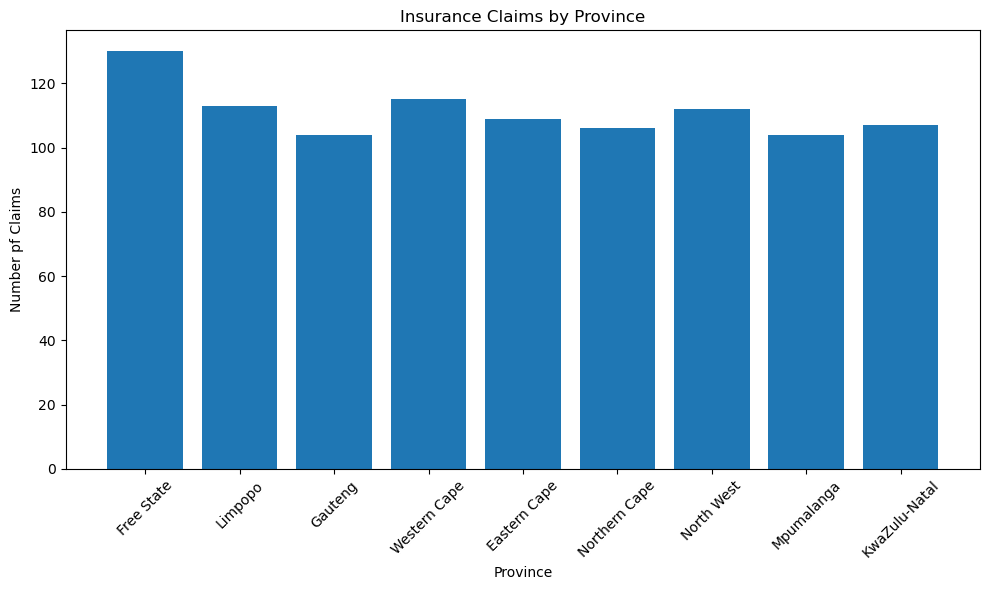

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(province_summary["province"],
        province_summary["total_claims"])

plt.title("Insurance Claims by Province")
plt.xlabel("Province")
plt.ylabel("Number pf Claims")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [15]:
print(province_summary["province"].tolist())

['Free State', 'Limpopo', 'Gauteng', 'Western Cape', 'Eastern Cape', 'Northern Cape', 'North West', 'Mpumalanga', 'KwaZulu-Natal']


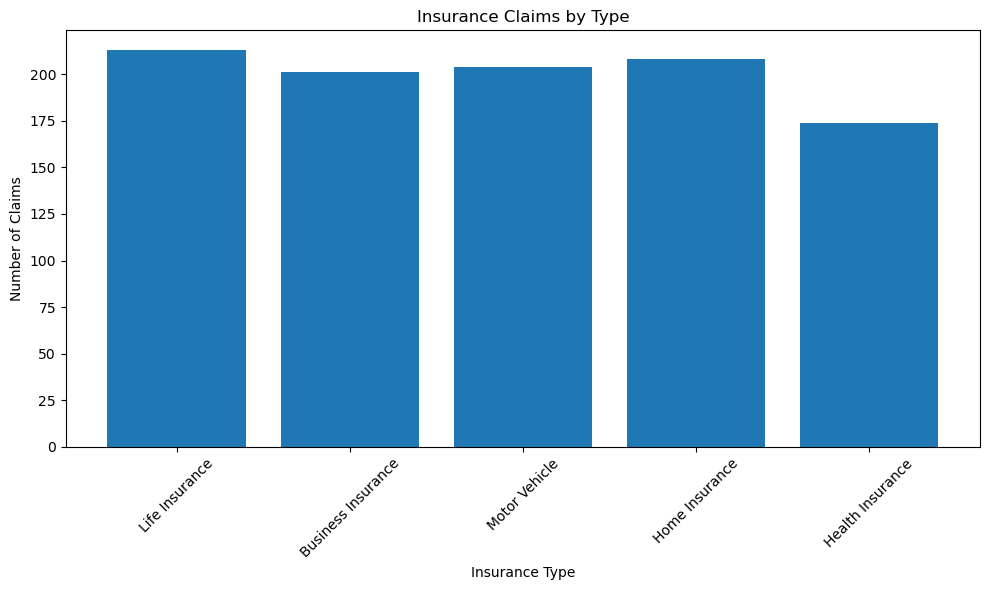

In [17]:
plt.figure(figsize=(10, 6))

plt.bar(type_summary["claim_types"],
        type_summary["total_claims"])

plt.title("Insurance Claims by Type")
plt.xlabel("Insurance Type")
plt.ylabel("Number of Claims")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

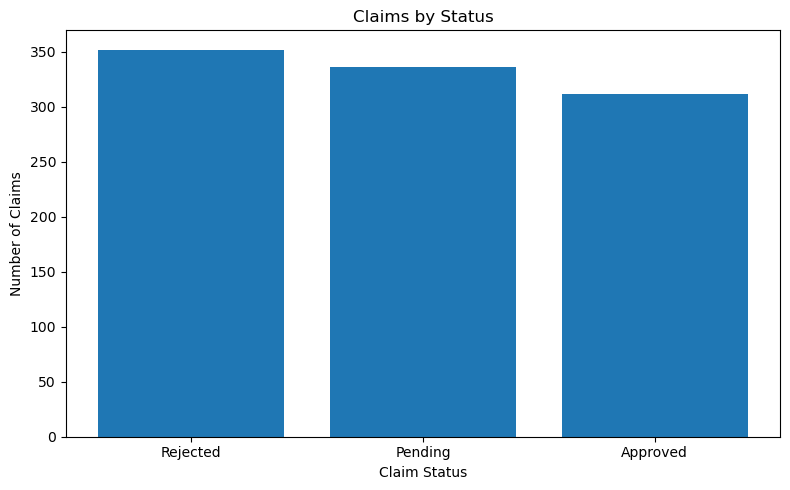

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(status_summary["claim_status"],
        status_summary["total_claims"])

plt.title("Claims by Status")
plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")

plt.tight_layout()

plt.show()

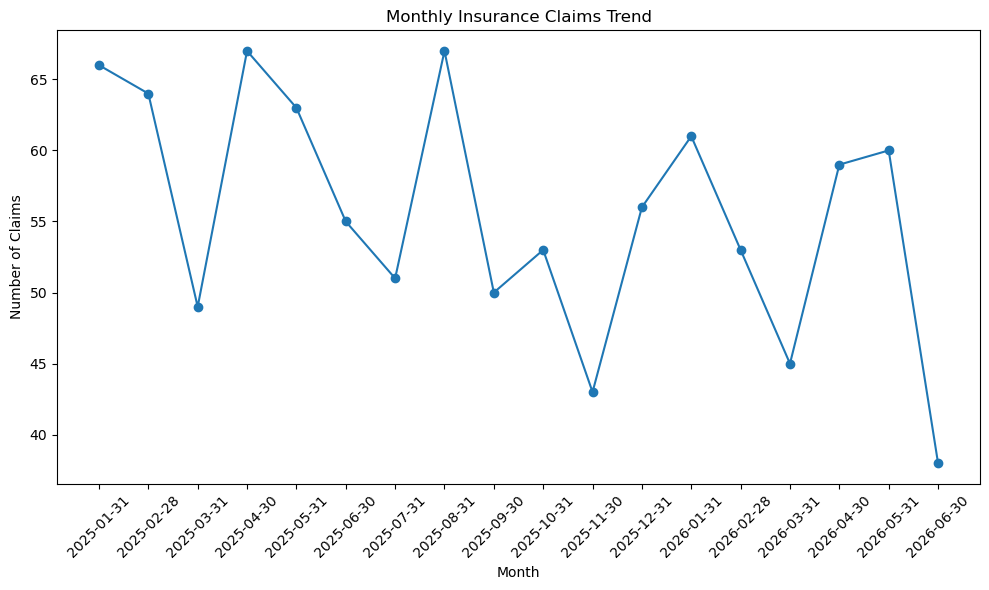

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(monthly_summary["claim_date"],
         monthly_summary["total_claims"],
         marker="o")

plt.title("Monthly Insurance Claims Trend")
plt.xlabel("Month")
plt.ylabel("Number of Claims")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

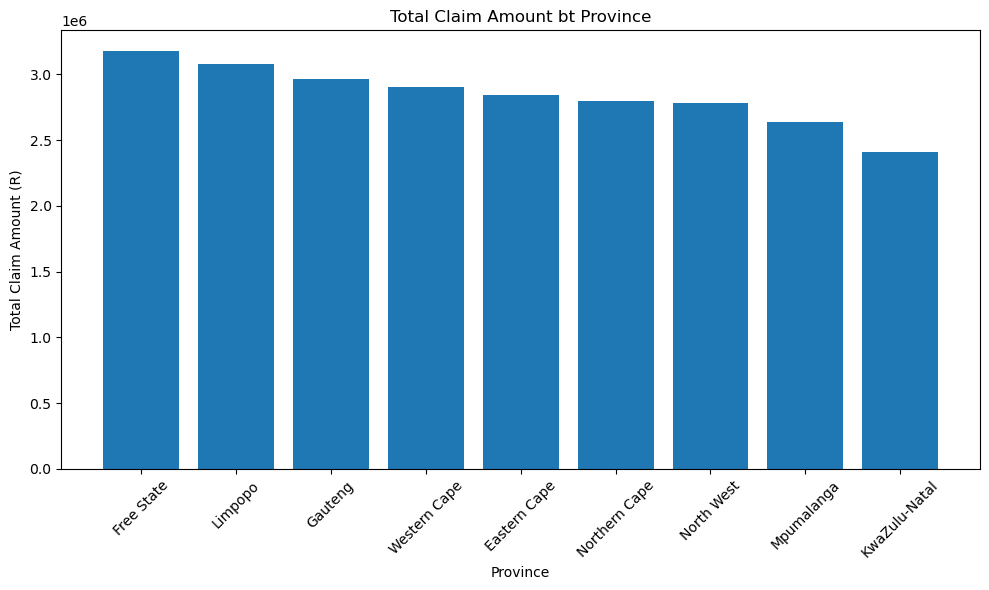

In [21]:
plt.figure(figsize=(10, 6))

plt.bar(province_summary["province"],
         province_summary["total_claim_amount"])

plt.title("Total Claim Amount bt Province")
plt.xlabel("Province")
plt.ylabel("Total Claim Amount (R)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [22]:
province_summary.to_csv("province_summary.csv", index=False)
type_summary.to_csv("type_summary.csv", index=False)
status_summary.to_csv("status_summary.csv", index=False)
monthly_summary.to_csv("monthly_summary.csv", index=False)

print("Summary files saved successfully!")

Summary files saved successfully!
